In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import PIL
import cv2
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
print("libraries initialized")

libraries initialized


In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, cache_dir='D:\Dataset', untar=True)
data_dir


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 48s 0us/step


'D:\\Dataset\\datasets\\flower_photos'

In [4]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('D:/Dataset/datasets/flower_photos')

In [5]:
images = list(data_dir.glob('*/*.jpg'))

print("Number of images:", len(images))
print(images) # it will convert the images to JPG format

Number of images: 3670
[WindowsPath('D:/Dataset/datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/102841525_bd6628ae3c.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/1031799732_e7f4008c03.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/10391248763_1d16681106_n.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/10437754174_22ec990b77_m.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/10437770546_8bb6f7bdd3_m.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/10437929963_bc13eebe0c.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/daisy/104

In [6]:
roses = list(data_dir.glob('roses/*'))
print(roses[:5]) 
print(len(roses))

[WindowsPath('D:/Dataset/datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/roses/10503217854_e66a804309.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]
641


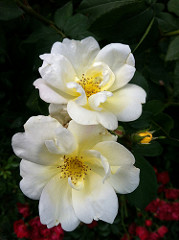

In [7]:
PIL.Image.open(roses[0])

[WindowsPath('D:/Dataset/datasets/flower_photos/tulips/100930342_92e8746431_n.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/tulips/10094729603_eeca3f2cb6.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/tulips/10094731133_94a942463c.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/tulips/10128546863_8de70c610d.jpg'), WindowsPath('D:/Dataset/datasets/flower_photos/tulips/10163955604_ae0b830975_n.jpg')]


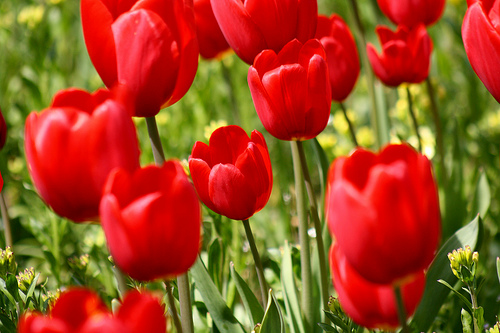

In [8]:
tulips = list(data_dir.glob('tulips/*'))
print(tulips[:5])   
PIL.Image.open(tulips[500])

In [9]:
flowers_images_dict = {
        'roses': list(data_dir.glob('roses/*')),
        'daisy': list(data_dir.glob('daisy/*')),
        'dandelion': list(data_dir.glob('dandelion/*')),
        'sunflowers': list(data_dir.glob('sunflowers/*')),
        'tulips': list(data_dir.glob('tulips/*')),
}


In [10]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2, 
    'sunflowers': 3,
    'tulips': 4,
}

In [11]:
img = cv2.imread(str(roses[0]))
img.shape

(240, 179, 3)

In [12]:
cv2.resize(img, (180,180)).shape

(180, 180, 3)

In [13]:
x, y = [], []



for flower_name, images in flowers_images_dict.items():
    for image in images:
            img = cv2.imread(str(image))
            img = cv2.resize(img, (180, 180))
            x.append(img)
            y.append(flowers_labels_dict[flower_name])
    

In [14]:
x = np.array(x)
y = np.array(y)

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
len(x_train)

2936

In [17]:
len(x_test)

734

In [18]:
x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0

In [19]:
x_train_scaled[0]

array([[[0.03529412, 0.49411765, 0.34117647],
        [0.04705882, 0.50196078, 0.35686275],
        [0.06666667, 0.52156863, 0.38431373],
        ...,
        [0.03921569, 0.29411765, 0.20392157],
        [0.05490196, 0.29803922, 0.21176471],
        [0.0627451 , 0.29803922, 0.20392157]],

       [[0.01176471, 0.45882353, 0.31764706],
        [0.01960784, 0.4745098 , 0.34117647],
        [0.02745098, 0.49019608, 0.36470588],
        ...,
        [0.03529412, 0.28627451, 0.18431373],
        [0.04313725, 0.28235294, 0.18431373],
        [0.04705882, 0.27843137, 0.18431373]],

       [[0.        , 0.41568627, 0.29019608],
        [0.        , 0.42745098, 0.31372549],
        [0.00392157, 0.45098039, 0.3372549 ],
        ...,
        [0.01960784, 0.26666667, 0.16470588],
        [0.01960784, 0.2627451 , 0.16078431],
        [0.02745098, 0.25490196, 0.15686275]],

       ...,

       [[0.02745098, 0.31764706, 0.11764706],
        [0.        , 0.21568627, 0.05490196],
        [0.01176471, 0

In [20]:
model = Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(180, 180, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

c:\Users\mdima\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [22]:
model.fit(x_train_scaled, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.4306 - loss: 1.3549 - val_accuracy: 0.5714 - val_loss: 1.0824
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.6082 - loss: 1.0046 - val_accuracy: 0.5867 - val_loss: 1.0177
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - accuracy: 0.6951 - loss: 0.7866 - val_accuracy: 0.6395 - val_loss: 0.9272
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.7981 - loss: 0.5542 - val_accuracy: 0.6514 - val_loss: 0.9290
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.8905 - loss: 0.3227 - val_accuracy: 0.6446 - val_loss: 1.1022
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - accuracy: 0.9412 - loss: 0.1833 - val_accuracy: 0.6650 - val_loss: 1.3070
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9770 - loss: 0.0808 - val_accuracy: 0.6497 - val_loss: 1.6564
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.9876 - loss: 0.0467 - val_accuracy: 0

In [23]:
model.evaluate(x_test_scaled, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6553 - loss: 2.1227


[2.1226871013641357, 0.6553133726119995]

In [24]:
predict = model.predict(x_test_scaled)
predict

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


array([[7.9788327e-01, 4.2465120e-10, 9.7001243e-09, 2.8443623e-07,
        2.0211641e-01],
       [2.1876020e-10, 8.0185303e-12, 6.7760419e-07, 9.9999893e-01,
        3.9255374e-07],
       [5.5916745e-02, 5.8918605e-03, 2.8084300e-04, 1.0451238e-01,
        8.3339810e-01],
       ...,
       [2.1016457e-04, 3.1591141e-01, 1.9262279e-04, 5.2187586e-01,
        1.6180997e-01],
       [1.6913024e-01, 4.5456383e-01, 3.7630290e-01, 1.0180958e-07,
        2.9878172e-06],
       [9.5640445e-01, 6.8508925e-05, 4.2515099e-02, 1.5421688e-04,
        8.5766084e-04]], shape=(734, 5), dtype=float32)

In [25]:
predict = model.predict(x_test_scaled)
predict[1]

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


array([2.1876020e-10, 8.0185303e-12, 6.7760419e-07, 9.9999893e-01,
       3.9255374e-07], dtype=float32)

In [26]:
flower_names = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

predict = model.predict(x_test_scaled)

for i in range(1):
    index = np.argmax(predict[i])
    probability = np.max(predict[i])
    flower = flower_names[index]
    print("Flower:", flower)
    print("Probability:", probability)
    print()

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Flower: daisy
Probability: 0.7978833



In [38]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

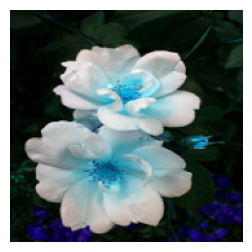

In [39]:
plt.figure(figsize=(3,5))
plt.axis('off')
plt.imshow(x[0])
plt.show()

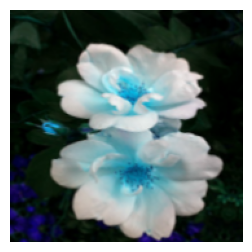

In [40]:
plt.figure(figsize=(3,5))
plt.axis('off')
plt.imshow(data_augmentation(x)[0].numpy().astype("uint8"))

In [41]:
model = tf.keras.Sequential([
    
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(5, activation='softmax')
])

In [42]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [45]:
history = model.fit(
    x_train_scaled, y_train, epochs=10, validation_split=0.2
)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.6819 - loss: 0.8252 - val_accuracy: 0.7228 - val_loss: 0.7279
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7027 - loss: 0.8039 - val_accuracy: 0.7092 - val_loss: 0.7290
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 44s 597ms/step - accuracy: 0.7095 - loss: 0.7856 - val_accuracy: 0.7024 - val_loss: 0.7514
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 50s 674ms/step - accuracy: 0.7185 - loss: 0.7644 - val_accuracy: 0.6820 - val_loss: 0.7737
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 38s 516ms/step - accuracy: 0.7223 - loss: 0.7483 - val_accuracy: 0.7194 - val_loss: 0.7136
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7112 - loss: 0.7619 - val_accuracy: 0.7092 - val_loss: 0.7465
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 36s 476ms/step - accuracy: 0.7125 - loss: 0.7485 - val_accuracy: 0.6888 - val_loss: 0.8091
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 40s 538ms/step - accuracy: 0.7185 - loss: 0.7369 - val_accuracy: 0.

In [44]:
loss, accuracy = model.evaluate(val_ds)

print("Loss:", loss)
print("Accuracy:", round(accuracy * 100, 2), "%")

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.7044 - loss: 0.7708
Loss: 0.7707650661468506
Accuracy: 70.44 %
